In [ ]:
#Hamza ALsihati
#2230006810
#8MA1



import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

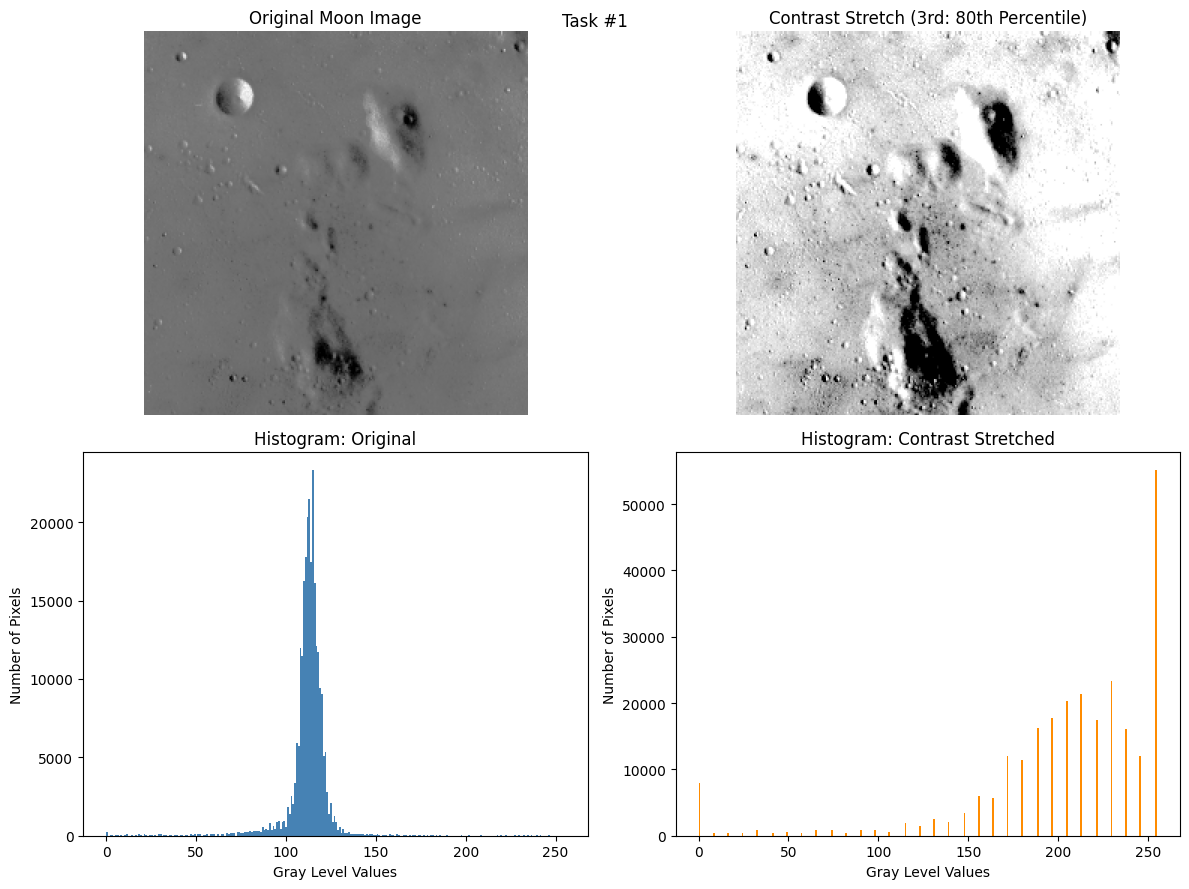

3rd percentile value : 87.00
80th percentile value: 118.00


In [ ]:
# Task 1
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

axes[1, 0].hist(img.ravel(), bins=256, range=(0, 255), color='steelblue', edgecolor='none')
axes[1, 0].set_title('Histogram: Original')
axes[1, 0].set_xlabel('Gray Level Values')
axes[1, 0].set_ylabel('Number of Pixels')

axes[0, 1].imshow(img_rescale, cmap='gray')
axes[0, 1].set_title('Contrast Stretch (3rd: 80th Percentile)')
axes[0, 1].axis('off')

axes[1, 1].hist(img_rescale.ravel(), bins=256, range=(0, 255), color='darkorange', edgecolor='none')
axes[1, 1].set_title('Histogram: Contrast Stretched')
axes[1, 1].set_xlabel('Gray Level Values')
axes[1, 1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.suptitle('Task #1')
plt.show()

print(f'3rd percentile value : {p3:.2f}')
print(f'80th percentile value: {p80:.2f}')

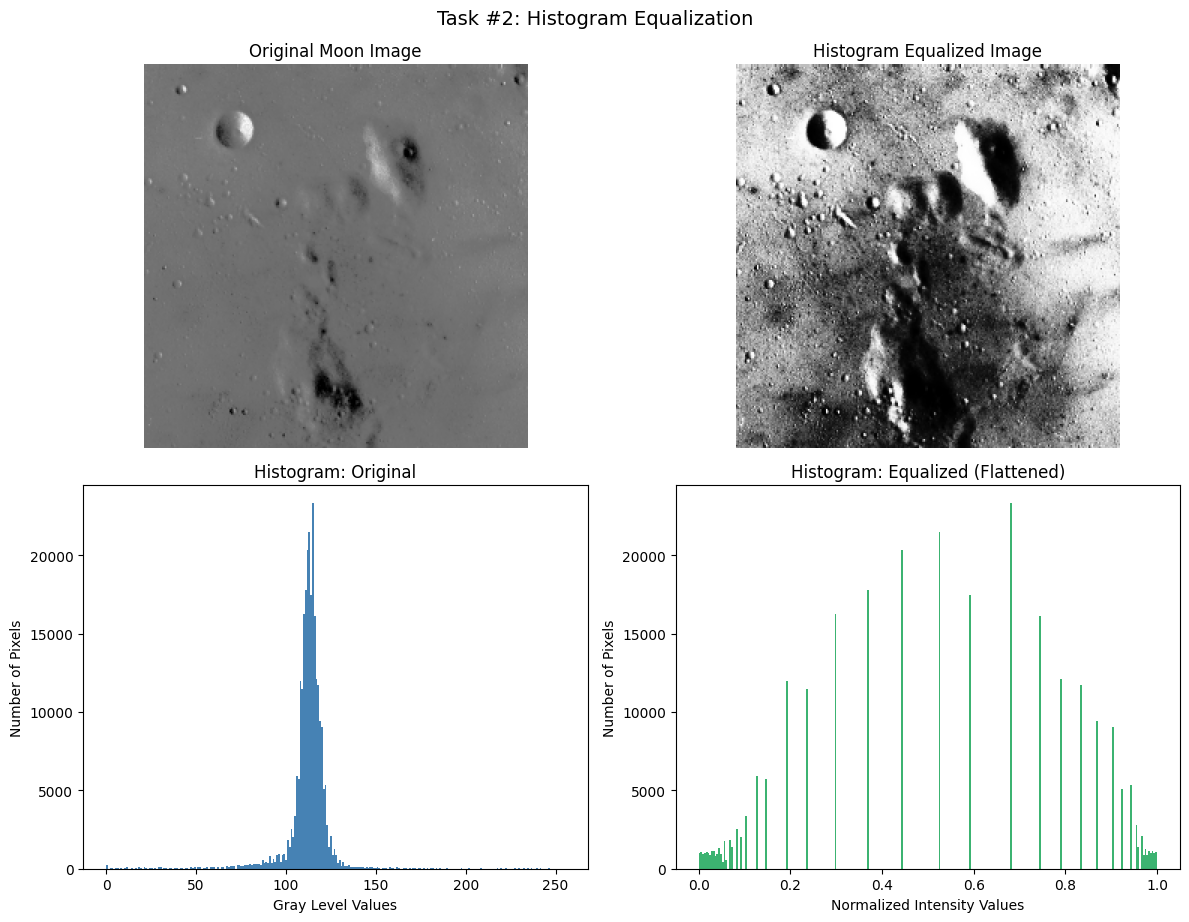

In [ ]:
# Task 2
img = data.moon()
img_equalized = exposure.equalize_hist(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Moon Image')
axes[0, 0].axis('off')

axes[1, 0].hist(img.ravel(), bins=256, range=(0, 255), color='steelblue', edgecolor='none')
axes[1, 0].set_title('Histogram: Original')
axes[1, 0].set_xlabel('Gray Level Values')
axes[1, 0].set_ylabel('Number of Pixels')

axes[0, 1].imshow(img_equalized, cmap='gray')
axes[0, 1].set_title('Histogram Equalized Image')
axes[0, 1].axis('off')

axes[1, 1].hist(img_equalized.ravel(), bins=256, range=(0, 1), color='mediumseagreen', edgecolor='none')
axes[1, 1].set_title('Histogram: Equalized (Flattened)')
axes[1, 1].set_xlabel('Normalized Intensity Values')
axes[1, 1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.suptitle('Task #2: Histogram Equalization', fontsize=14, y=1.02)
plt.show()

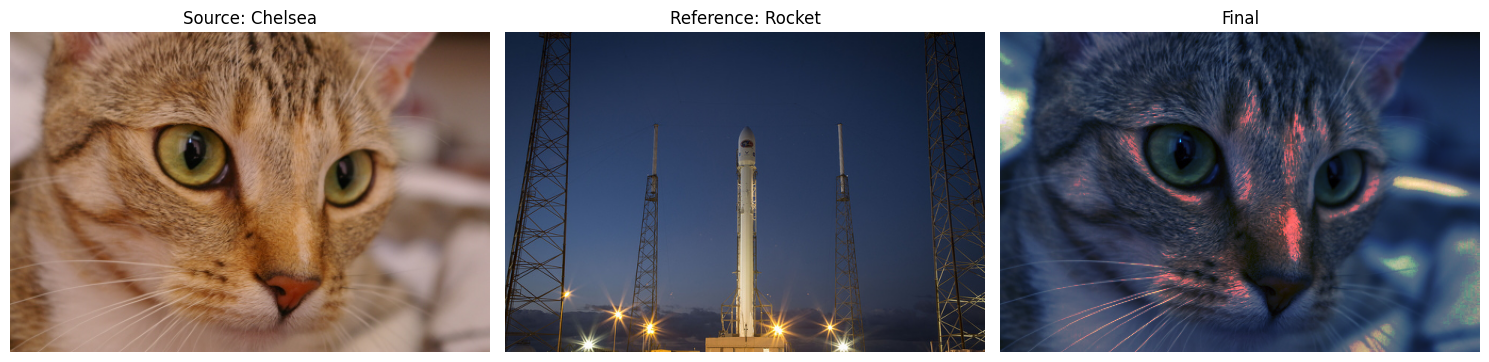

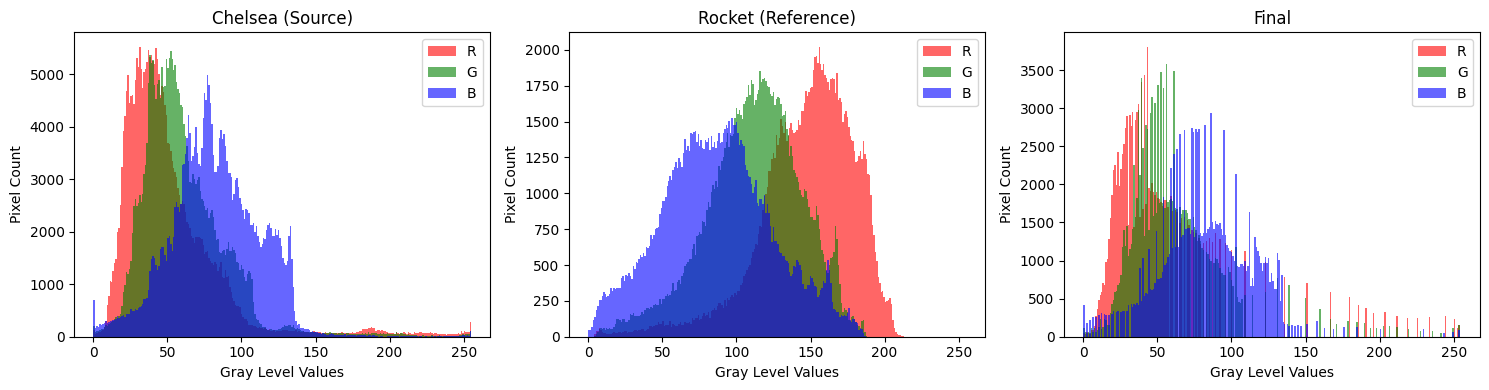

In [ ]:
# Task 3
from skimage.exposure import match_histograms

imgRocket = data.rocket()
imgChelsea = data.chelsea()

matched = match_histograms(imgChelsea, imgRocket, channel_axis=2)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imgChelsea)
axes[0].set_title('Source: Chelsea')
axes[0].axis('off')

axes[1].imshow(imgRocket)
axes[1].set_title('Reference: Rocket')
axes[1].axis('off')

axes[2].imshow(matched.astype(np.uint8))
axes[2].set_title('Final')
axes[2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_colors = ('red', 'green', 'blue')
channel_names  = ('R', 'G', 'B')

for c, (color, name) in enumerate(zip(channel_colors, channel_names)):
    axes[0].hist(imgRocket[:, :, c].ravel(),   bins=256, range=(0,255), alpha=0.6, color=color, label=name)
    axes[1].hist(imgChelsea[:, :, c].ravel(), bins=256, range=(0,255), alpha=0.6, color=color, label=name)
    axes[2].hist(matched[:, :, c].ravel(),  bins=256, range=(0,255), alpha=0.6, color=color, label=name)

titles = ['Chelsea (Source)', 'Rocket (Reference)', 'Final']
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel('Gray Level Values')
    ax.set_ylabel('Pixel Count')
    ax.legend()

plt.tight_layout()
plt.show()